In [2]:
import scanpy as sc

pancreas_path = "../data/raw/Pancreas_TSP1_30_version2d_10X_smartseq_scvi_Nov122024.h5ad"
ovary_path   = "../data/raw/Ovary_TSP1_30_version2d_10X_smartseq_scvi_Nov262024.h5ad"

v1_codes = [f"TSP{i}" for i in range(1, 16)]
v2_codes = ["TSP17", "TSP19", "TSP20", "TSP21", "TSP25", "TSP26", "TSP27", "TSP28", "TSP30"]

adata = sc.read_h5ad(ovary_path)
print(adata)
adata.obs.head()


AnnData object with n_obs × n_vars = 48951 × 61806
    obs: 'donor', 'tissue', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'old_index', 'assay', 'sample_id', 'replicate', '10X_run', '10X_barcode', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_ontology_class', 'cell_ontology_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'age', 'sex', 'ethnicity', 'scvi_leiden_res05_tissue', 'sample_number'
    var: 'ensembl_id', 'gene_symbol', 'genome', 'mt', 'ercc', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mean', 'std'
    uns: '_scvi_manager_uuid', '_scvi_uuid', '_training_mode', 'age_colors', 'assay_colors', 'compartment_colors', 'donor_colors', 'leide

,donor,tissue,anatomical_position,method,cdna_plate,library_plate,notes,cdna_well,old_index,assay,...,total_counts_ercc,pct_counts_ercc,_scvi_batch,_scvi_labels,scvi_leiden_donorassay_full,age,sex,ethnicity,scvi_leiden_res05_tissue,sample_number
TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9,TSP30,Ovary,NA,smartseq,Blue,B105390,Live,D9,TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9_S8...,SS3,...,0.0,0.000000,6,0,10,26,female,Hispanic,0,1
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22,TSP30,Ovary,NA,smartseq,Blue,B105394,Live,E22,TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22_S...,SS3,...,247215.0,70.390112,6,0,5,26,female,Hispanic,17,1
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_P4,TSP30,Ovary,NA,smartseq,Blue,B105394,Live,P4,TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_P4_S7...,SS3,...,370638.0,64.099713,6,0,10,26,female,Hispanic,0,1
TSP30_Ovary_NA_SS3_B004411_B105393_LiveDead_I1,TSP30,Ovary,NA,smartseq,B004411,B105393,Live,I1,TSP30_Ovary_NA_SS3_B004411_B105393_LiveDead_I1...,SS3,...,1.0,0.006053,6,0,10,26,female,Hispanic,0,1
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_O4,TSP30,Ovary,NA,smartseq,Blue,B105394,Live,O4,TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_O4_S7...,SS3,...,288860.0,59.845404,6,0,10,26,female,Hispanic,0,1


An attempt at abstracting the columns:

In [3]:
semantic_groups = {
    "Sample Metadata": [
        "donor", "tissue", "assay", "sample_id", "replicate",
        "10X_run", "method", "anatomical_position"
    ],
    
    "QC & Filtering": [
        "n_genes_by_counts", "total_counts",
        "total_counts_mt", "pct_counts_mt",
        "total_counts_ercc", "pct_counts_ercc"
    ],
    
    "Dimensionality & Batch": [
        "_scvi_batch", "scvi_leiden_donorassay_full", "scvi_leiden_res05_tissue",
        "_scvi_labels"
    ],
    
    "Cell Types & Annotations": [
        "cell_ontology_class", "cell_ontology_id",
        "broad_cell_class", "free_annotation",
        "manually_annotated", "published_2022"
    ],
    
    "Demographics & Biology": [
        "age", "sex", "ethnicity", "compartment", "tissue", "anatomical_position"
    ],
    
    "Other / Notes": [
        "donor_method", "donor_tissue", "donor_assay",
        "donor_tissue_assay", "sample_number", "old_index",
        "cdna_plate", "library_plate", "cdna_well",
        "10X_barcode", "ambient_removal", "notes"
    ]
}

In [4]:
all_grouped_cols = {c for cols in semantic_groups.values() for c in cols}
obs_cols = set(adata.obs.columns)
missing = obs_cols - all_grouped_cols
extra   = all_grouped_cols - obs_cols
print("Columns not in any group:", missing)
print("Typos / non-existent in obs:", extra)

Columns not in any group: set()
Typos / non-existent in obs: set()


Display data using the categories of columns mentioned above

In [5]:
for group, cols in semantic_groups.items():
    print(f"\n— {group} ({len(cols)} cols) —")
    display(adata.obs[cols].head(2)) 


— Sample Metadata (8 cols) —


,donor,tissue,assay,sample_id,replicate,10X_run,method,anatomical_position
TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9,TSP30,Ovary,SS3,TSP30_Ovary_NA_SS3_Blue_B105390_Live,1,nan,smartseq,NA
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22,TSP30,Ovary,SS3,TSP30_Ovary_NA_SS3_Blue_B105394_Live,1,nan,smartseq,NA



— QC & Filtering (6 cols) —


,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ercc,pct_counts_ercc
TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9,2161,10543.0,2469.0,23.418382,0.0,0.000000
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22,4755,351207.0,18481.0,5.262139,247215.0,70.390112



— Dimensionality & Batch (4 cols) —


...

,cell_ontology_class,cell_ontology_id,broad_cell_class,free_annotation,manually_annotated,published_2022
TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9,smooth muscle cell,CL:0000192,contractile cell,smooth muscle cell,True,False
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22,endothelial cell,CL:0000115,endothelial cell,endothelial cell,True,False



— Demographics & Biology (6 cols) —


,age,sex,ethnicity,compartment,tissue,anatomical_position
TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9,26,female,Hispanic,Stromal,Ovary,NA
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22,26,female,Hispanic,Endothelium,Ovary,NA



— Other / Notes (12 cols) —


,donor_method,donor_tissue,donor_assay,donor_tissue_assay,sample_number,old_index,cdna_plate,library_plate,cdna_well,10X_barcode,ambient_removal,notes
TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9,TSP30_smartseq,TSP30_Ovary,TSP30_SS3,TSP30_Ovary_SS3,1,TSP30_Ovary_NA_SS3_Blue_B105390_LiveDead_D9_S8...,Blue,B105390,D9,nan,None,Live
TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22,TSP30_smartseq,TSP30_Ovary,TSP30_SS3,TSP30_Ovary_SS3,1,TSP30_Ovary_NA_SS3_Blue_B105394_LiveDead_E22_S...,Blue,B105394,E22,nan,None,Live


Display the top 10 types in each category sorted in descending order

In [6]:

annotation_col = semantic_groups["Cell Types & Annotations"]

for col in annotation_col:
    counts = adata.obs[col].value_counts(dropna=False)
    print(f"— {col} —")
    print(f"Unique categories: {counts.size}")
    print(counts.head(10).to_string(), "\n")


— cell_ontology_class —
Unique categories: 28
cell_ontology_class
stromal cell of ovary              35003
blood vessel smooth muscle cell     5987
stromal cell                        2159
endothelial cell                    1724
smooth muscle cell                  1271
theca cell                          1038
granulosa cell                       655
macrophage                           404
ovarian surface epithelial cell      241
glandular epithelial cell            235 

— cell_ontology_id —
Unique categories: 27
cell_ontology_id
CL:0002132    35003
CL:0019018     6642
CL:0000499     2159
CL:0000115     1724
CL:0000192     1271
CL:0000503     1038
CL:0000235      404
CL:2000064      241
CL:0000150      235
CL:0000625       73 

— broad_cell_class —
Unique categories: 15
broad_cell_class
stromal cell                 38200
contractile cell              7258
endothelial cell              1724
meso-epithelial cell           655
myeloid leukocyte              411
epithelial cell          

Plot distribution of cells by type. Pick the annotation type from the "Cell Types & Annotations" semantic group.

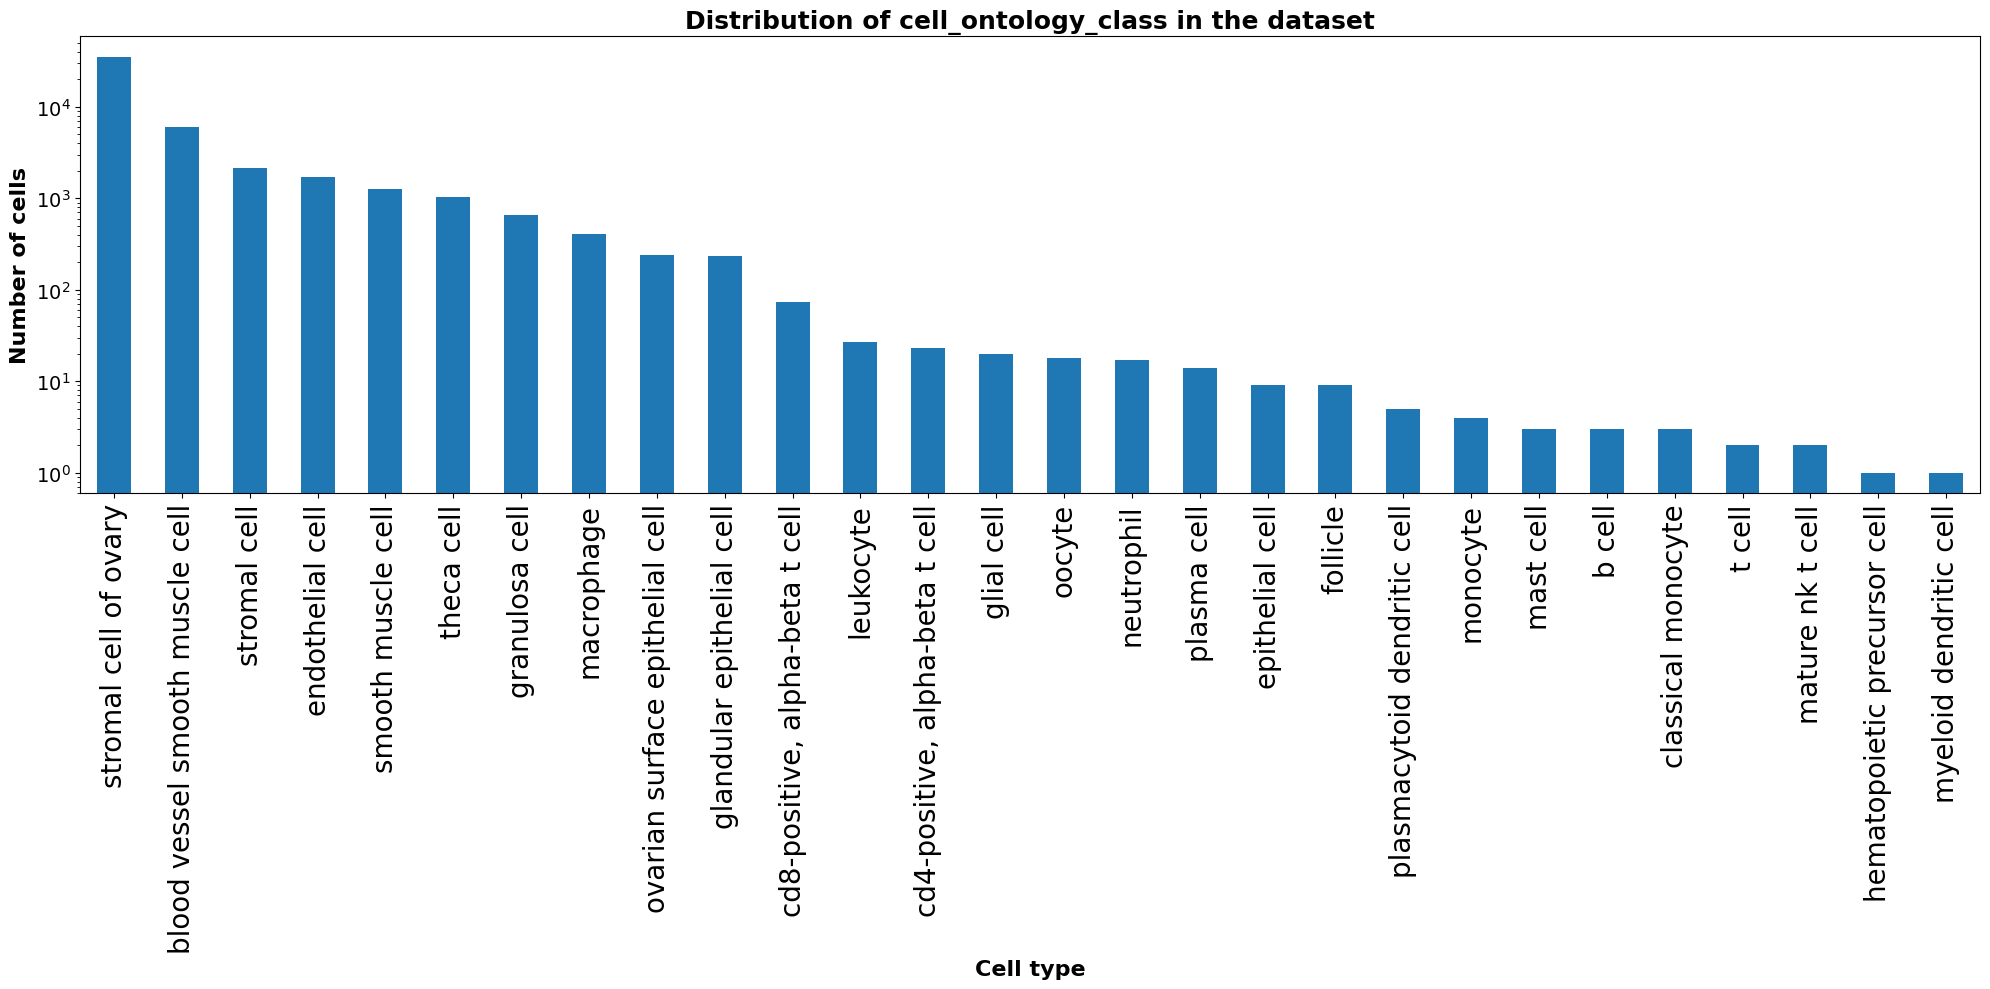

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 20,
    'ytick.labelsize': 14,
})

# Change the cell type column here
celltype_col = 'cell_ontology_class'

ct_counts = adata.obs[celltype_col].value_counts()

fig, ax = plt.subplots(figsize=(20,10))
ct_counts.plot(kind='bar', logy=True, ax=ax)

ax.set_ylabel("Number of cells")  
ax.set_xlabel("Cell type")
ax.set_title(f"Distribution of {celltype_col} in the dataset")

plt.tight_layout()
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)

Pie chart of cell type percentages.

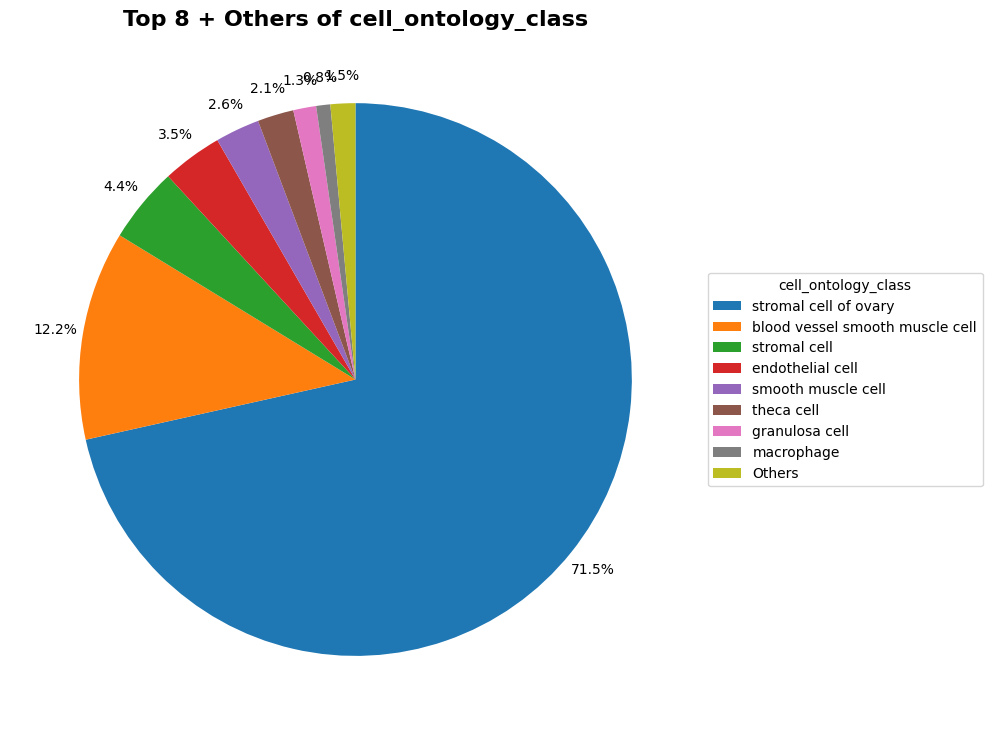

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Change the cell type column and top N here
celltype_col = 'cell_ontology_class'
top_n = 8


ct_counts = adata.obs[celltype_col].value_counts()
top       = ct_counts.iloc[:top_n]
others    = ct_counts.iloc[top_n:].sum()
plot_counts = pd.concat([top, pd.Series({'Others': others})])


fig, ax = plt.subplots(figsize=(10,10))
wedges, texts, autotexts = ax.pie(
    plot_counts.values,
    labels=None,           
    autopct='%1.1f%%',  
    pctdistance=1.1,    
    startangle=90,
    counterclock=False
)


ax.legend(
    wedges,
    plot_counts.index,
    title=celltype_col,
    bbox_to_anchor=(1, 0.5),
    loc='center left'
)


ax.set_ylabel('')
ax.set_title(
    f"Top {top_n} + Others of {celltype_col}",
    fontweight='bold',
    fontsize=16
)

plt.tight_layout()
plt.show()

Bar chart of cell distribution within donors, label colors dont match with the pie chart ones.

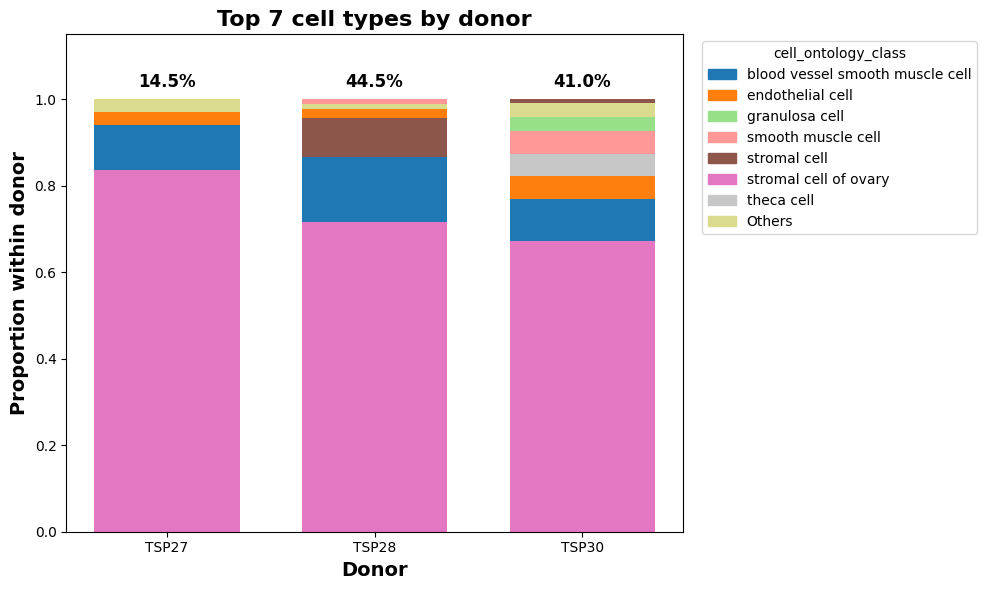

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_celltype_distribution_by_donor_sorted(
    adata,
    celltype_col='cell_ontology_class',
    top_n=7,
    figsize=(10,6),
    bar_width=0.7,
    cmap_name='tab20'
):

    series = adata.obs[celltype_col]
    top = series.value_counts().index[:top_n]
    series = (series
              .astype('category')
              .cat.add_categories(['Others'])
              .where(series.isin(top), other='Others'))

    ct_donor = pd.crosstab(adata.obs['donor'], series)
    ct_prop  = ct_donor.div(ct_donor.sum(axis=1), axis=0)
    donor_frac = ct_donor.sum(axis=1) / ct_donor.values.sum()

    donors    = ct_prop.index.tolist()
    all_ct    = ct_prop.columns.tolist()
    x_positions = np.arange(len(donors))

    cmap   = plt.get_cmap(cmap_name)
    colors = {ct: cmap(i / len(all_ct)) for i,ct in enumerate(all_ct)}

    fig, ax = plt.subplots(figsize=figsize)

    for i, donor in enumerate(donors):
        bottom = 0.0
    
        for ct, prop in ct_prop.loc[donor].sort_values(ascending=False).items():
            ax.bar(
                x_positions[i],
                prop,
                bar_width,
                bottom=bottom,
                color=colors[ct]
            )
            bottom += prop

    handles = [plt.Rectangle((0,0),1,1, color=colors[ct]) for ct in all_ct]
    ax.legend(
        handles,
        all_ct,
        title=celltype_col,
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    for i, frac in enumerate(donor_frac):
        ax.text(
            x_positions[i], 1.02,
            f"{frac*100:.1f}%",
            ha='center', va='bottom',
            fontsize=12, fontweight='bold'
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(donors, rotation=0)
    ax.set_ylabel("Proportion within donor", fontsize=14, fontweight='bold')
    ax.set_xlabel("Donor",               fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_title(
        f"Top {top_n} cell types by donor",
        fontsize=16, fontweight='bold'
    )
    plt.tight_layout()
    return fig, ax


fig, ax = plot_celltype_distribution_by_donor_sorted(adata)
plt.show()
